# Actividad 1. Segmentación de clientes mediante Aprendizaje No Supervisado 

## Introducción

### Objetivos

Aplicar técnicas de aprendizaje no supervisado para segmentar clientes en función de sus características demográficas y de consumo, con el fin de identificar patrones ocultos y grupos homogéneos que puedan orientar decisiones de marketing y estrategias comerciales. 

### Conjunto de datos:
Este dataset contiene 200 registros de clientes con variables como edad, ingresos anuales y puntuación de gasto.  
Mall Customers Dataset (Kaggle): [https://www.kaggle.com/datasets/shwetabh123/mall-customers](https://www.kaggle.com/datasets/shwetabh123/mall-customers)

## Informe
### 1. Análisis exploratorio del conjunto de datos
- Carga del dataset. 
- Análisis descriptivo de las variables. 
- Identificación de posibles valores atípicos.

#### 1.1. Imports

In [30]:
# imports:

import kagglehub
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
)
import os

#### 1.2. Estilos


In [31]:
FONDO   = "#11151c"
TEXTO   = "#e6edf3"
ACENTO  = "#4fd1c5"
REJILLA = "#2a313c"
PALETA  = ["#4fd1c5", "#f6c177", "#c191f2", "#7aa2f7", "#f7768e", "#9ece6a"]

sns.set_theme(style="darkgrid")
mpl.rcParams.update({
    # Fondos
    "figure.facecolor":  FONDO,
    "axes.facecolor":    FONDO,
    "savefig.facecolor": FONDO,
    # Textos y ejes
    "text.color":        TEXTO,
    "axes.labelcolor":   TEXTO,
    "xtick.color":       TEXTO,
    "ytick.color":       TEXTO,
    "axes.edgecolor":    REJILLA,
    "grid.color":        REJILLA,
    # Títulos: turquesa, en negrita y alineados a la izquierda
    "axes.titlecolor":    ACENTO,
    "axes.titlesize":     15,
    "axes.titleweight":   "bold",
    "axes.titlelocation": "left",
    "axes.titlepad":      12,
    # Tamaños y leyenda por defecto
    "figure.figsize": (6, 4),
    "font.size":      11,
    "legend.frameon": False,
})
sns.set_palette(PALETA)

print("Estilos aplicados. Paleta:", PALETA)


Estilos aplicados. Paleta: ['#4fd1c5', '#f6c177', '#c191f2', '#7aa2f7', '#f7768e', '#9ece6a']


#### 1.3. Carga del DataSet e inicialización

In [45]:
# Carpeta donde se guardarán las figuras para el informe
os.makedirs("figuras", exist_ok=True)

# Descarga el dataset de Kaggle y carga el CSV en un DataFrame de pandas
CSV_PATH = kagglehub.dataset_download("shwetabh123/mall-customers") + "/Mall_Customers.csv"

df = pd.read_csv(CSV_PATH)

display(df.head())

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


#### 1.4. Análisis general


In [33]:
# Información general del dataset
print(f"- Dimensiones del dataset (shape): {df.shape}\n")
print("- Información de las variables:")
df.info()

- Dimensiones del dataset (shape): (200, 5)

- Información de las variables:
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Genre                   200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 8.9 KB


- Vemos que no tenemos nulls. 
- "Genre" es de tipo "object". Lo cambiaremos a tipo "category" para una mejor eficiencia y coherencia.

In [34]:
df['Genre'] = df['Genre'].astype('category')

#### 1.5. Análisis de las variables no numéricas
- Únicamente Genre (Male y Female)

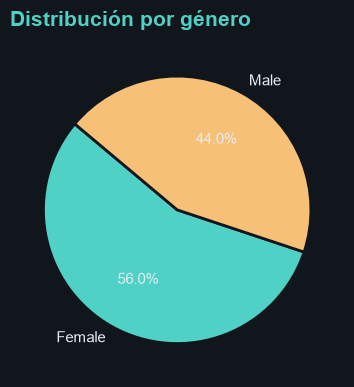

Genre
Female    112
Male       88
Name: count, dtype: int64


In [35]:
# Análisis de la variable categórica (Genre): Male / Female
conteo_genero = df["Genre"].value_counts()

plt.figure(figsize=(4, 4))
plt.pie(
    conteo_genero,
    labels=conteo_genero.index,
    autopct="%1.1f%%",
    startangle=140,
    colors=PALETA[:len(conteo_genero)],
    textprops={"color": TEXTO},
    wedgeprops={"edgecolor": FONDO, "linewidth": 2},
)
plt.title("Distribución por género")
plt.tight_layout()
plt.show()

print(conteo_genero)


#### 1.6. Análisis de las variables numéricas


In [36]:
# Análisis de las variables numéricas relevantes
print("\n    - Estadísticas descriptivas de las variables numéricas:")
display(df[["Age", "Annual Income (k$)", "Spending Score (1-100)"]].describe())



    - Estadísticas descriptivas de las variables numéricas:


,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000
mean,38.850000,60.560000,50.200000
std,13.969007,26.264721,25.823522
min,18.000000,15.000000,1.000000
25%,28.750000,41.500000,34.750000
50%,36.000000,61.500000,50.000000
75%,49.000000,78.000000,73.000000
max,70.000000,137.000000,99.000000


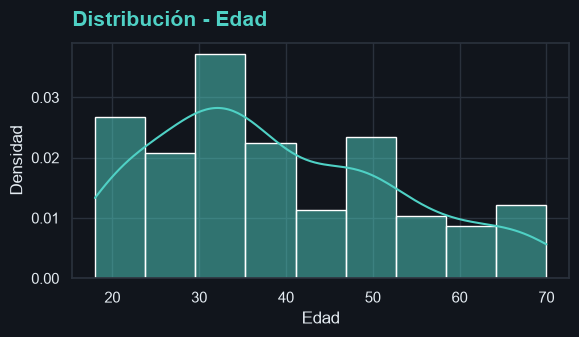

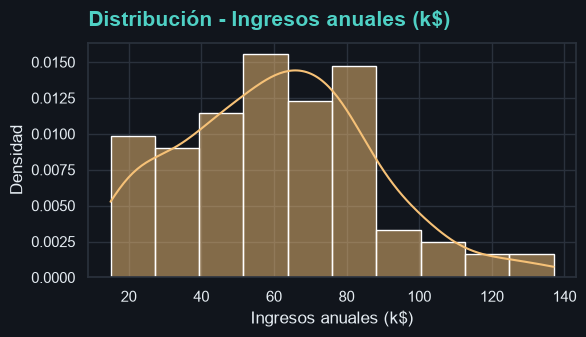

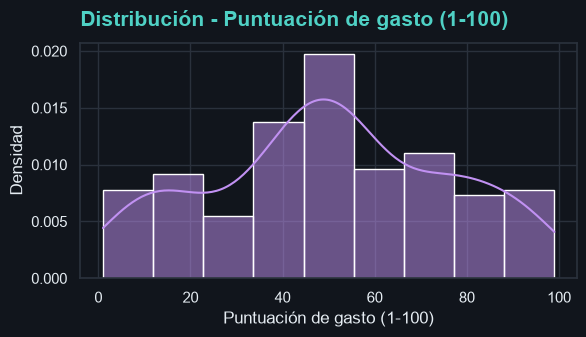

In [37]:
# Distribución de cada variable numérica
variables_num = [
    ("Age", "Edad"),
    ("Annual Income (k$)", "Ingresos anuales (k$)"),
    ("Spending Score (1-100)", "Puntuación de gasto (1-100)"),
]

for (columna, etiqueta), color in zip(variables_num, PALETA):
    plt.figure(figsize=(6, 3.5))
    sns.histplot(df[columna], kde=True, color=color, stat="density")
    plt.title(f"Distribución - {etiqueta}")
    plt.xlabel(etiqueta)
    plt.ylabel("Densidad")
    plt.tight_layout()
    plt.show()


#### 1.7. Valores atípicos

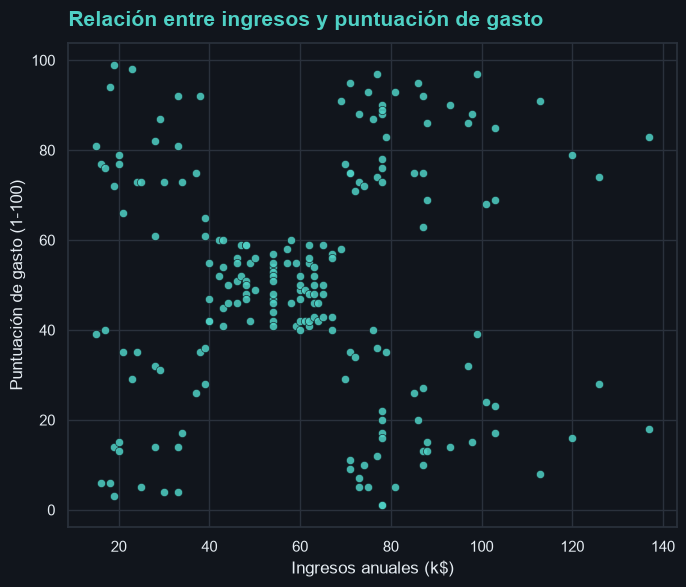

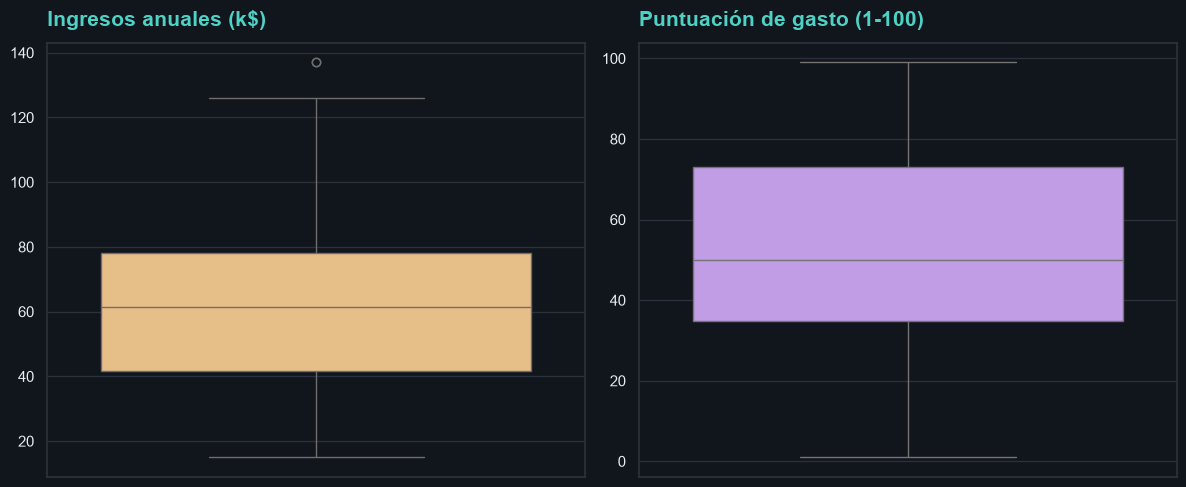

In [38]:
# Búsqueda de posibles valores atípicos
# 1) Relación entre ingresos y puntuación de gasto
plt.figure(figsize=(7, 6))
plt.scatter(
    df["Annual Income (k$)"],
    df["Spending Score (1-100)"],
    s=35,
    alpha=0.85,
    color=PALETA[0],
    edgecolor=FONDO,
    linewidth=0.5,
)
plt.xlabel("Ingresos anuales (k$)")
plt.ylabel("Puntuación de gasto (1-100)")
plt.title("Relación entre ingresos y puntuación de gasto")
plt.tight_layout()
plt.show()

# 2) Diagramas de caja
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.boxplot(data=df, y="Annual Income (k$)", color=PALETA[1])
plt.title("Ingresos anuales (k$)")
plt.ylabel("")
plt.subplot(1, 2, 2)
sns.boxplot(data=df, y="Spending Score (1-100)", color=PALETA[2])
plt.title("Puntuación de gasto (1-100)")
plt.ylabel("")
plt.tight_layout()
plt.show()


El diagrama de dispersión no muestra puntos claramente despegados de la nube principal. En los diagramas de caja, la edad y la puntuación de gasto no presentan valores fuera de los bigotes.
En los ingresos anuales aparece un punto por encima del bigote superior (>130k$). Será tratado como un cliente real de renta alta. Como además es justo el tipo de perfil que puede definir un segmento de interés, se conserva en el análisis y no se elimina ningún registro.

### 2. Preprocesamiento 
- Limpieza de datos. 
- Escalado de variables numéricas. 
- Selección de variables relevantes para el clustering. 

Para el clustering se utilizan las dos variables que describen directamente el comportamiento de consumo: **Annual Income (k$)** y **Spending Score (1-100)**. Trabajar con estas dos variables permite además representar los grupos directamente en un plano 2D, sin necesidad de reducir la dimensionalidad, lo que facilita la interpretación de los segmentos.

Se descartan `CustomerID`, que es un mero identificador sin valor descriptivo, y `Genre`, una variable categórica que no encaja en una distancia euclídea sobre datos estandarizados. La variable `Age`, aunque se ha analizado en el apartado anterior, se mantiene fuera del clustering para conservar la representación en dos dimensiones; su incorporación se plantea como posible mejora en las conclusiones.

Como ambas variables están en escalas distintas (miles de dólares y una puntuación de 1 a 100), se estandarizan con `StandardScaler` para que pesen por igual en el cálculo de distancias.

In [39]:
# OBJETIVO: dejar las 2 variables con media=0 y desviación típica=1, para que pesen por igual.

# Subconjunto sin escalar: escalas muy diferentes entre variables
df_num = df[["Annual Income (k$)", "Spending Score (1-100)"]]
print("ANTES del escalado:")
print(df_num.describe().loc[["mean", "std", "min", "max"]].round(2))

# Aplicar StandardScaler
scaler = StandardScaler()
df_scaled_fit = scaler.fit_transform(df_num)   # fit aprende μ y σ, transform las aplica

# Reconstruir DataFrame (fit_transform devuelve un array sin nombres)
df_scaled_fit = pd.DataFrame(df_scaled_fit,
                             columns=["Annual Income (k$)", "Spending Score (1-100)"])

# Estado posterior: todas centradas y normalizadas
print("\nDESPUÉS del escalado:")
print(df_scaled_fit.describe().loc[["mean", "std", "min", "max"]].round(2))

df_scaled_fit.head()

ANTES del escalado:
      Annual Income (k$)  Spending Score (1-100)
mean               60.56                   50.20
std                26.26                   25.82
min                15.00                    1.00
max               137.00                   99.00

DESPUÉS del escalado:
      Annual Income (k$)  Spending Score (1-100)
mean               -0.00                   -0.00
std                 1.00                    1.00
min                -1.74                   -1.91
max                 2.92                    1.89


,Annual Income (k$),Spending Score (1-100)
0,-1.738999,-0.434801
1,-1.738999,1.195704
2,-1.700830,-1.715913
3,-1.700830,1.040418
4,-1.662660,-0.395980



### 3. Aplicación de técnicas de clustering
- Entrena al menos dos métodos distintos (por ejemplo: K-Means, DBSCAN, Agglomerative Clustering).
- Determina el número óptimo de clusters usando métodos como Elbow Method o Silhouette Score.

In [46]:
# Trabajamos sobre las dos variables ya estandarizadas (Income y Spending)
X = df_scaled_fit.values


# ------------------------------------------------------------------
# Función de evaluación REUTILIZADA del material de la asignatura.
# Calcula las métricas internas y excluye el ruido (-1) de DBSCAN antes
# de medir, devolviendo NaN cuando no hay al menos 2 grupos válidos.
# ------------------------------------------------------------------
def evaluar_clustering(X_eval, labels, nombre_modelo, parametro):
    labels = np.asarray(labels)

    mask_validos = labels != -1
    labels_validos = labels[mask_validos]

    n_noise = int(np.sum(labels == -1))
    clusters_sin_ruido = sorted(set(labels_validos))
    n_clusters = len(clusters_sin_ruido)

    resultado = {
        "modelo": nombre_modelo,
        "parametro": parametro,
        "n_clusters": n_clusters,
        "n_ruido": n_noise,
        "silhouette": np.nan,
        "davies_bouldin": np.nan,
        "calinski_harabasz": np.nan
    }

    if n_clusters < 2:
        return resultado

    X_metric = X_eval[mask_validos]

    # Si tras excluir ruido queda un solo grupo o muy pocos puntos, no se calculan métricas.
    if len(np.unique(labels_validos)) < 2 or len(X_metric) <= n_clusters:
        return resultado

    resultado["silhouette"] = silhouette_score(X_metric, labels_validos)
    resultado["davies_bouldin"] = davies_bouldin_score(X_metric, labels_validos)
    resultado["calinski_harabasz"] = calinski_harabasz_score(X_metric, labels_validos)

    return resultado

#### 3.1. K-Means y búsqueda del número de grupos

K-Means exige fijar de antemano el número de grupos k. Para elegirlo, entrenamos el modelo para varios valores de k (de 2 a 8) y, en cada caso, guardamos:

- la **inercia** (suma de distancias al cuadrado de cada punto a su centroide)
    - Base del *método del codo*
- las métricas internas (**Silhouette**, **Davies-Bouldin** y **Calinski-Harabasz**).

Fijamos `random_state=42` y `n_init=20` para que el resultado sea reproducible.

In [47]:
# Entrenamos K-Means para distintos valores de k y recogemos sus métricas
filas_kmeans = []
kmeans_por_k = {}

for k in range(2, 9):
    modelo = KMeans(n_clusters=k, random_state=42, n_init=20)
    etiquetas = modelo.fit_predict(X)

    fila = evaluar_clustering(X, etiquetas, "K-Means", k)
    fila["inercia"] = modelo.inertia_

    filas_kmeans.append(fila)
    kmeans_por_k[k] = (modelo, etiquetas)

resultados_kmeans = pd.DataFrame(filas_kmeans)
display(resultados_kmeans.round(4))

,modelo,parametro,n_clusters,n_ruido,silhouette,davies_bouldin,calinski_harabasz,inercia
0,K-Means,2,2,0,0.3213,1.2670,95.6694,269.6910
1,K-Means,3,3,0,0.4666,0.7165,151.3351,157.7040
2,K-Means,4,4,0,0.4939,0.7096,174.5952,108.9213
3,K-Means,5,5,0,0.5547,0.5722,248.6493,65.5684
4,K-Means,6,6,0,0.5399,0.6546,243.0879,55.0573
5,K-Means,7,7,0,0.5281,0.7148,254.6212,44.8648
6,K-Means,8,8,0,0.4567,0.7579,267.9142,37.1481


#### 3.2. Método del codo y Silhouette

Representamos la inercia y el coeficiente de Silhouette frente a `k`. El **codo** marca el punto a partir del cual añadir más grupos apenas reduce la inercia; la **Silhouette** debe ser lo más alta posible. El número de grupos ideal es aquel en el que ambas señales coinciden.

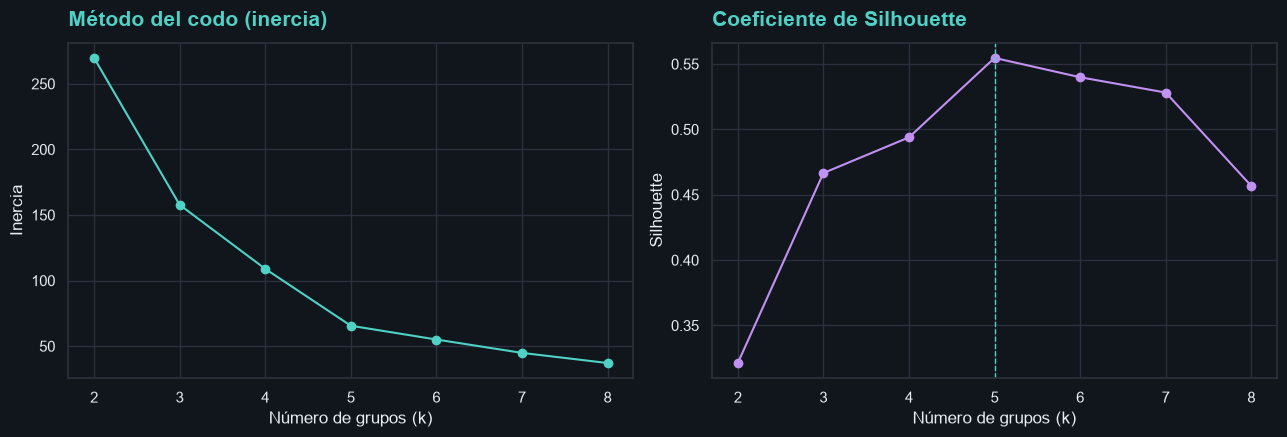

- El mayor Silhouette se alcanza en k = 5.


In [48]:
# Comparativa visual para elegir k: codo (inercia) y Silhouette
fig, (ax_codo, ax_sil) = plt.subplots(1, 2, figsize=(13, 4.5))

ax_codo.plot(resultados_kmeans["parametro"], resultados_kmeans["inercia"], marker="o", color=PALETA[0])
ax_codo.set_title("Método del codo (inercia)")
ax_codo.set_xlabel("Número de grupos (k)")
ax_codo.set_ylabel("Inercia")

ax_sil.plot(resultados_kmeans["parametro"], resultados_kmeans["silhouette"], marker="o", color=PALETA[2])
ax_sil.set_title("Coeficiente de Silhouette")
ax_sil.set_xlabel("Número de grupos (k)")
ax_sil.set_ylabel("Silhouette")

# Resaltamos el k con mayor Silhouette
k_optimo = int(resultados_kmeans.loc[resultados_kmeans["silhouette"].idxmax(), "parametro"])
ax_sil.axvline(k_optimo, color=ACENTO, linestyle="--", linewidth=1)

plt.tight_layout()
plt.savefig("figuras/kmeans_codo_silhouette.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"- El mayor Silhouette se alcanza en k = {k_optimo}.")

Tanto el codo como la Silhouette señalan el mismo valor: a partir de **k = 5** la inercia deja de bajar de forma apreciable y la Silhouette alcanza su máximo (≈ 0,55), con la Davies-Bouldin también en su mínimo. Nos quedamos, por tanto, con **5 grupos** para K-Means.

#### 3.3. DBSCAN

A diferencia de K-Means, DBSCAN no necesita fijar el número de grupos: los descubre por **densidad** y, además, etiqueta como **ruido** (-1) los puntos que no encajan en ninguna región densa. Sus dos parámetros son `eps` (radio del vecindario) y `min_samples` (vecinos mínimos para formar un núcleo). Probamos varios valores de `eps` con `min_samples=5` y observamos cuántos grupos y cuánto ruido produce cada configuración.

In [ ]:
# Barrido de eps para DBSCAN (min_samples fijo en 5).
# La rejilla de valores de eps y el min_samples se toman del material de la asignatura.
filas_dbscan = []
dbscan_por_eps = {}

for eps in [0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50, 0.60]:
    modelo = DBSCAN(eps=eps, min_samples=5)
    etiquetas = modelo.fit_predict(X)

    fila = evaluar_clustering(X, etiquetas, "DBSCAN", eps)
    fila["inercia"] = np.nan   # no aplica a DBSCAN

    filas_dbscan.append(fila)
    dbscan_por_eps[eps] = (modelo, etiquetas)

resultados_dbscan = pd.DataFrame(filas_dbscan)
display(resultados_dbscan.round(4))

#### 3.4. Comparación de las dos técnicas

Reunimos los resultados de K-Means y DBSCAN en una única tabla para compararlos y localizar la mejor solución según cada métrica interna.

In [44]:
# Tabla conjunta de ambos métodos y mejor solución según cada métrica
resultados = pd.concat([resultados_kmeans, resultados_dbscan], ignore_index=True)
columnas = ["modelo", "parametro", "n_clusters", "n_ruido",
            "silhouette", "davies_bouldin", "calinski_harabasz", "inercia"]
display(resultados[columnas].round(4))

# Selección automática de la mejor solución por cada criterio
mejor_sil = resultados.loc[resultados["silhouette"].idxmax()]
mejor_db = resultados.loc[resultados["davies_bouldin"].idxmin()]

print(f"- Mejor Silhouette: {mejor_sil['modelo']} "
      f"(parámetro {mejor_sil['parametro']}) = {mejor_sil['silhouette']:.4f} "
      f"con {int(mejor_sil['n_ruido'])} puntos de ruido")
print(f"- Mejor Davies-Bouldin: {mejor_db['modelo']} "
      f"(parámetro {mejor_db['parametro']}) = {mejor_db['davies_bouldin']:.4f}")

,modelo,parametro,n_clusters,n_ruido,silhouette,davies_bouldin,calinski_harabasz,inercia
0,K-Means,2.00,2,0,0.3213,1.2670,95.6694,269.6910
1,K-Means,3.00,3,0,0.4666,0.7165,151.3351,157.7040
2,K-Means,4.00,4,0,0.4939,0.7096,174.5952,108.9213
3,K-Means,5.00,5,0,0.5547,0.5722,248.6493,65.5684
4,K-Means,6.00,6,0,0.5399,0.6546,243.0879,55.0573
5,K-Means,7.00,7,0,0.5281,0.7148,254.6212,44.8648
6,K-Means,8.00,8,0,0.4567,0.7579,267.9142,37.1481
7,DBSCAN,0.20,7,77,0.5856,0.4637,173.2619,NaN
8,DBSCAN,0.25,6,50,0.5317,0.5580,181.1659,NaN
9,DBSCAN,0.30,7,35,0.5243,0.5800,185.5758,NaN


- Mejor Silhouette: DBSCAN (parámetro 0.2) = 0.5856 con 77 puntos de ruido
- Mejor Davies-Bouldin: DBSCAN (parámetro 0.2) = 0.4637


Conviene leer la tabla con sentido crítico. DBSCAN llega a una Silhouette ligeramente superior, pero lo consigue **descartando como ruido una parte importante de los clientes** (cuanto menor es `eps`, mayor es la Silhouette y mayor es el ruido). Para nuestro objetivo —segmentar a *toda* la clientela en grupos accionables— esa solución no es práctica.

K-Means con **k = 5** asigna los 200 clientes a 5 grupos bien definidos sin dejar a nadie fuera, con una Silhouette muy próxima a la mejor. Es, por tanto, la solución que llevaremos al análisis e interpretación de la sección 4. DBSCAN aporta una lectura complementaria útil: señala qué clientes quedan en zonas poco densas (posibles perfiles atípicos).

### 4. Visualización y análisis de los resultados 
- Representación gráfica de los clusters (2D/3D). 
- Interpretación de las características principales de cada grupo. 
- Comparación de los resultados obtenidos con cada método. 

### 5. Conclusiones y posibles aplicaciones 
- Discute cómo podrían emplearse los resultados en un contexto real (segmentación de mercado, campañas personalizadas, etc.). 
- Identifica limitaciones y posibles mejoras. 